Step 2: Load Data and Conduct Auto-EDA for Analysis of Dataset

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

file_path = "/Users/brandonacosta/Documents/GitHub/text-analytics-spring-2026/assignment_2/data/raw/IMDB Dataset.csv"
df = pd.read_csv(file_path)

df.head()

,review,sentiment
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fact that it goes where other shows wouldn't dare. Forget pretty pictures painted for mainstream audiences, forget charm, forget romance...OZ doesn't mess around. The first episode I ever saw struck me as so nasty it was surreal, I couldn't say I was ready for it, but as I watched more, I developed a taste for Oz, and got accustomed to the high levels of graphic violence. Not just violence, but injustice (crooked guards who'll be sold out for a nickel, inmates who'll kill on order and get away with it, well mannered, middle class inmates being turned into prison bitches due to their lack of street skills or prison experience) Watching Oz, you may become comfortable with what is uncomfortable viewing....thats if you can get in touch with your darker side.",positive
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only ""has got all the polari"" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of the great master's of comedy and his life. <br /><br />The realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional 'dream' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell's murals decorating every surface) are terribly well done.",positive
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted comedy. The plot is simplistic, but the dialogue is witty and the characters are likable (even the well bread suspected serial killer). While some may be disappointed when they realize this is not Match Point 2: Risk Addiction, I thought it was proof that Woody Allen is still fully in control of the style many of us have grown to love.<br /><br />This was the most I'd laughed at one of Woody's comedies in years (dare I say a decade?). While I've never been impressed with Scarlet Johanson, in this she managed to tone down her ""sexy"" image and jumped right into a average, but spirited young woman.<br /><br />This may not be the crown jewel of his career, but it was wittier than ""Devil Wears Prada"" and more interesting than ""Superman"" a great comedy to go see with friends.",positive
3,"Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zom

In [31]:
print("number of rows:", df.shape[0])
print("number of columns:", df.shape[1])

number of rows: 50000
number of columns: 2


In [33]:
print("column names:")
print(df.columns.tolist())

column names:
['review', 'sentiment']


In [35]:
print("\ndata types:")
print(df.dtypes)


data types:
review       object
sentiment    object
dtype: object


In [37]:
missing_values = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_values

,missing_count,missing_percent
review,0,0.0
sentiment,0,0.0


In [39]:
target_distribution = pd.DataFrame({
    "count": df["sentiment"].value_counts(),
    "percent": df["sentiment"].value_counts(normalize=True).mul(100).round(2)
})

target_distribution

,count,percent
sentiment,,
positive,25000,50.0
negative,25000,50.0


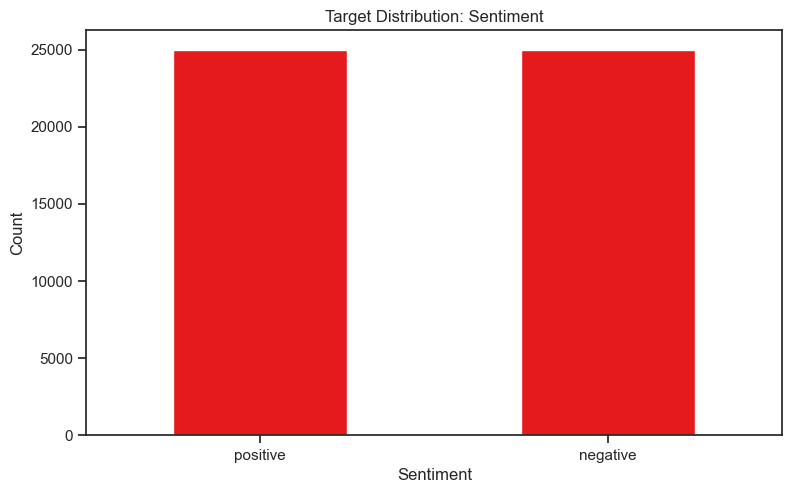

In [41]:
df["sentiment"].value_counts().plot(kind="bar")
plt.title("Target Distribution: Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [51]:
df["char_count"] = df["review"].astype(str).str.len()
df["word_count"] = df["review"].astype(str).str.split().str.len()

length_summary = df.groupby("sentiment")[["char_count", "word_count"]].agg(["mean", "median", "std"])
length_summary.round(2)

char_count                 word_count               
             mean    median   std       mean    median   std  
sentiment                                                     
negative    1294.06   973.0   945.89   229.46    174.0  164.95
positive    1324.80   968.0  1031.49   232.85    172.0  177.50

Shape of your Data Set loaded: (1000, 4)
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#######################################################################################
Classifying variables in data set...
    3 Predictors classified...
        No variables removed since no ID or low-information variables found in data set
Since Number of Rows in data 1000 exceeds maximum, randomly sampling 1000 rows for EDA...

################ Binary_Classification problem #####################
    All variables classified into correct types.


,Data Type,Missing Values%,Unique Values%,Minimum Value,Maximum Value,DQ Issue
review,object,0.000000,100,,,No issue
char_count,int64,0.000000,78,209.000000,6230.000000,Column has 83 outliers greater than upper bound (2951.50) or lower than lower bound(-668.50). Cap them or remove them.
word_count,int64,0.000000,41,37.000000,1010.000000,"Column has 74 outliers greater than upper bound (533.00) or lower than lower bound(-123.00). Cap them or remove them., Column has a high correlation with ['char_count']. Consider dropping one of them."
sentiment,object,0.000000,0,,,Target column


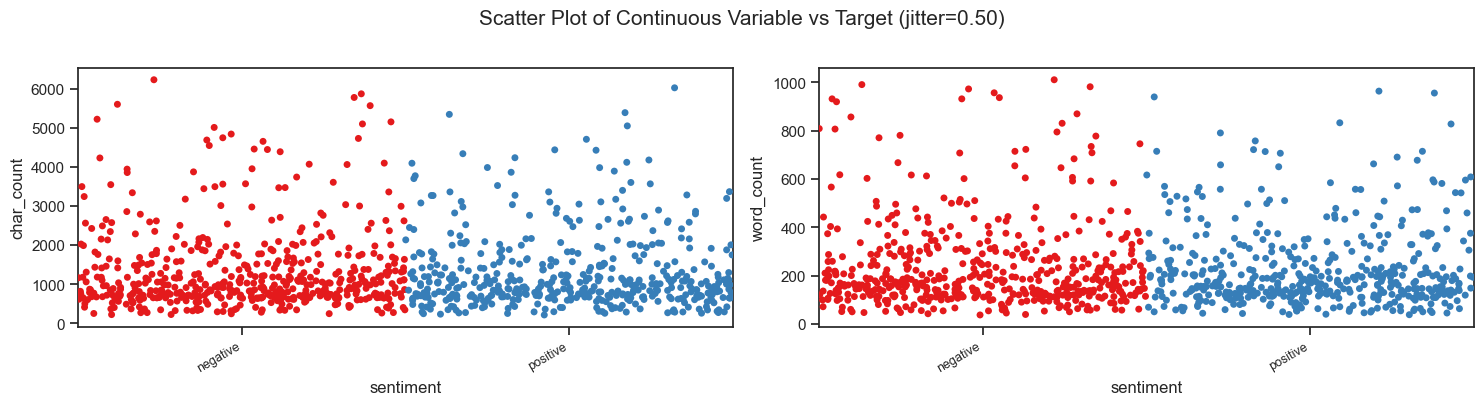

Total Number of Scatter Plots = 3


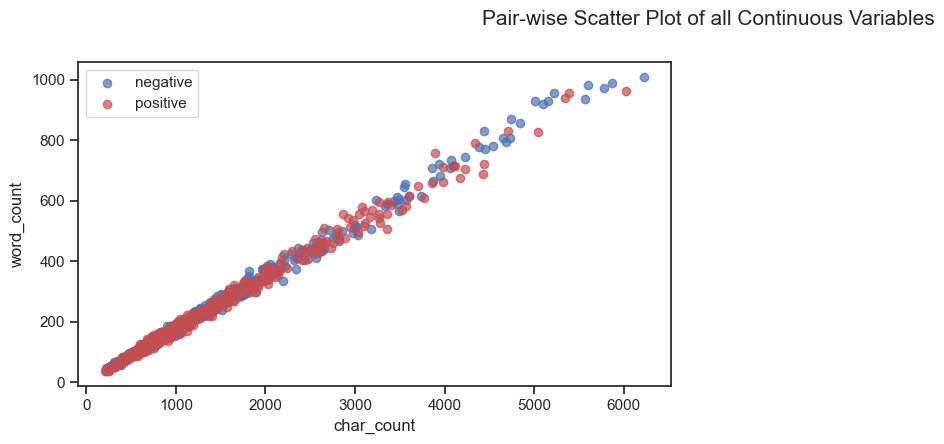

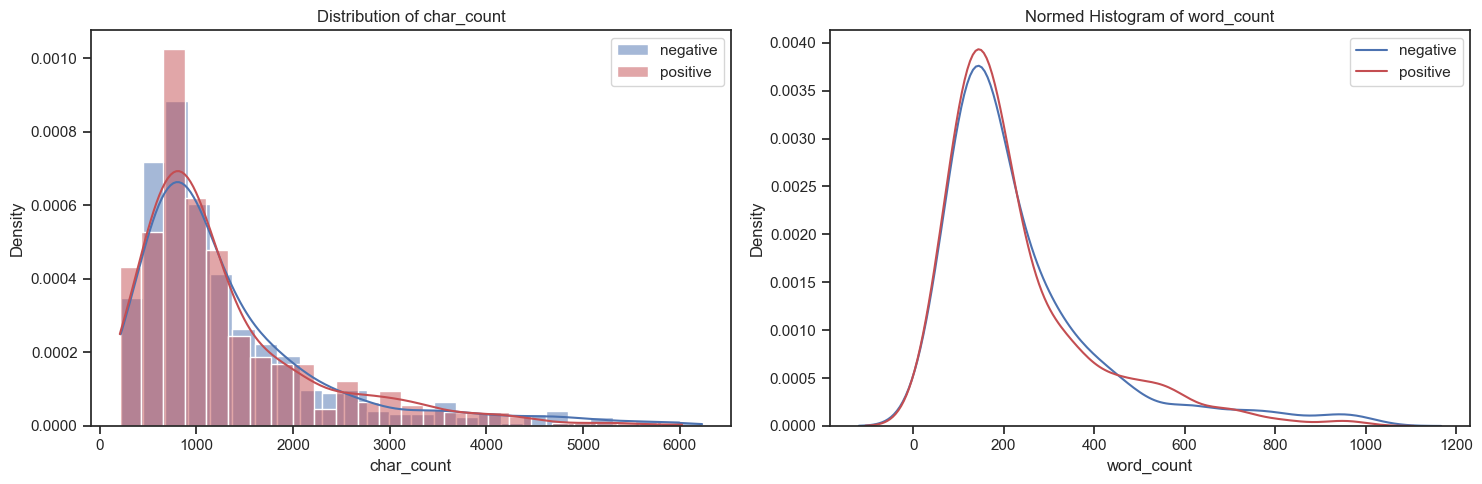

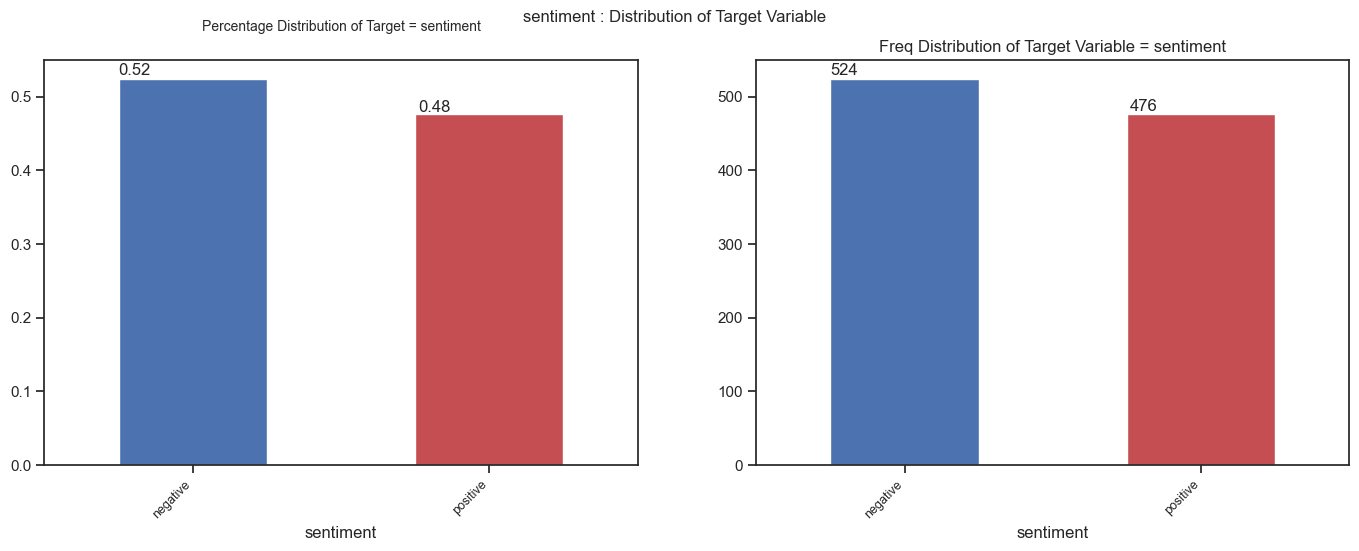

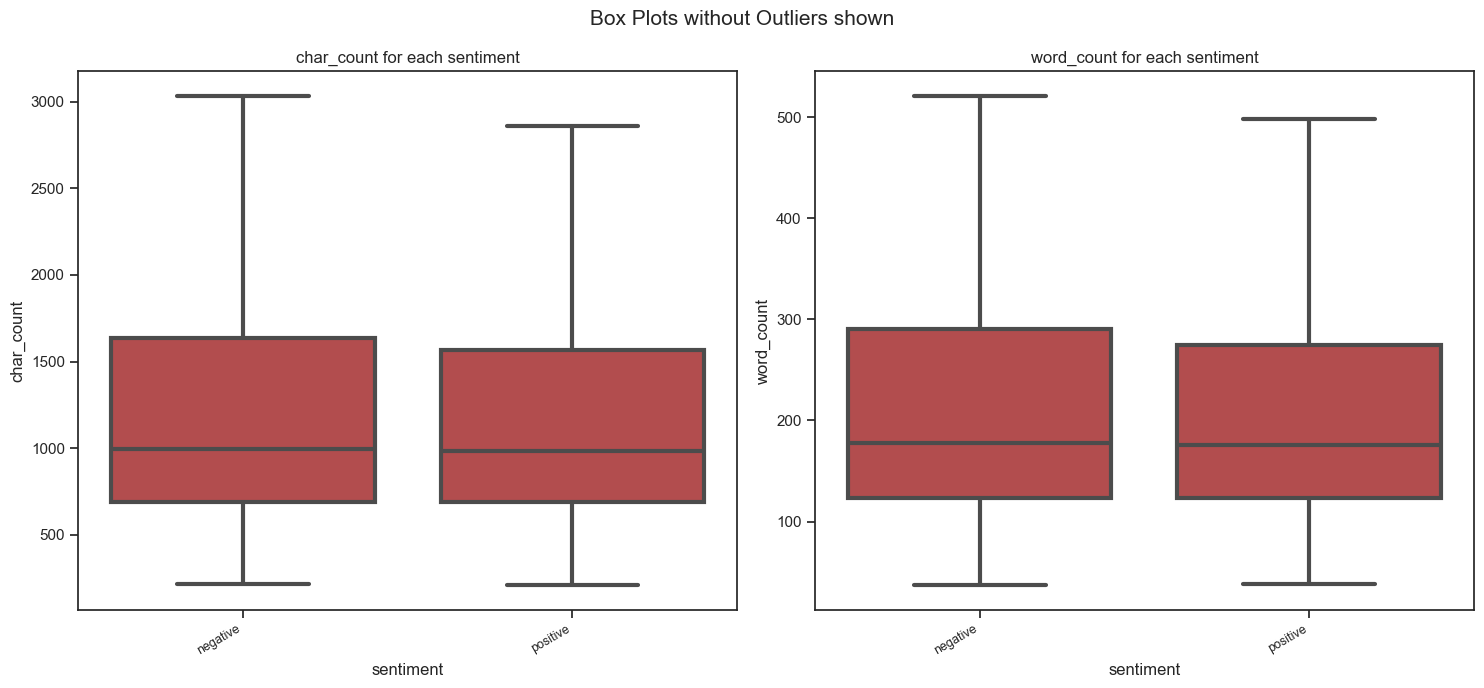

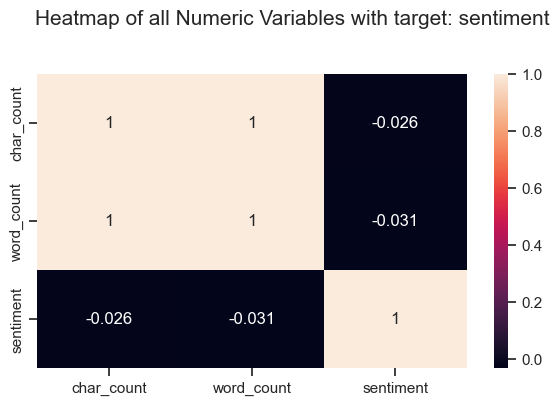

[nltk_data] Downloading collection 'popular'
[nltk_data]    | 
[nltk_data]    | Downloading package cmudict to
[nltk_data]    |     /Users/brandonacosta/nltk_data...
[nltk_data]    |   Package cmudict is already up-to-date!
[nltk_data]    | Downloading package gazetteers to
[nltk_data]    |     /Users/brandonacosta/nltk_data...
[nltk_data]    |   Package gazetteers is already up-to-date!
[nltk_data]    | Downloading package genesis to
[nltk_data]    |     /Users/brandonacosta/nltk_data...
[nltk_data]    |   Package genesis is already up-to-date!
[nltk_data]    | Downloading package gutenberg to
[nltk_data]    |     /Users/brandonacosta/nltk_data...
[nltk_data]    |   Package gutenberg is already up-to-date!
[nltk_data]    | Downloading package inaugural to
[nltk_data]    |     /Users/brandonacosta/nltk_data...
[nltk_data]    |   Package inaugural is already up-to-date!
[nltk_data]    | Downloading package movie_reviews to
[nltk_data]    |     /Users/brandonacosta/nltk_data...
[nltk_dat

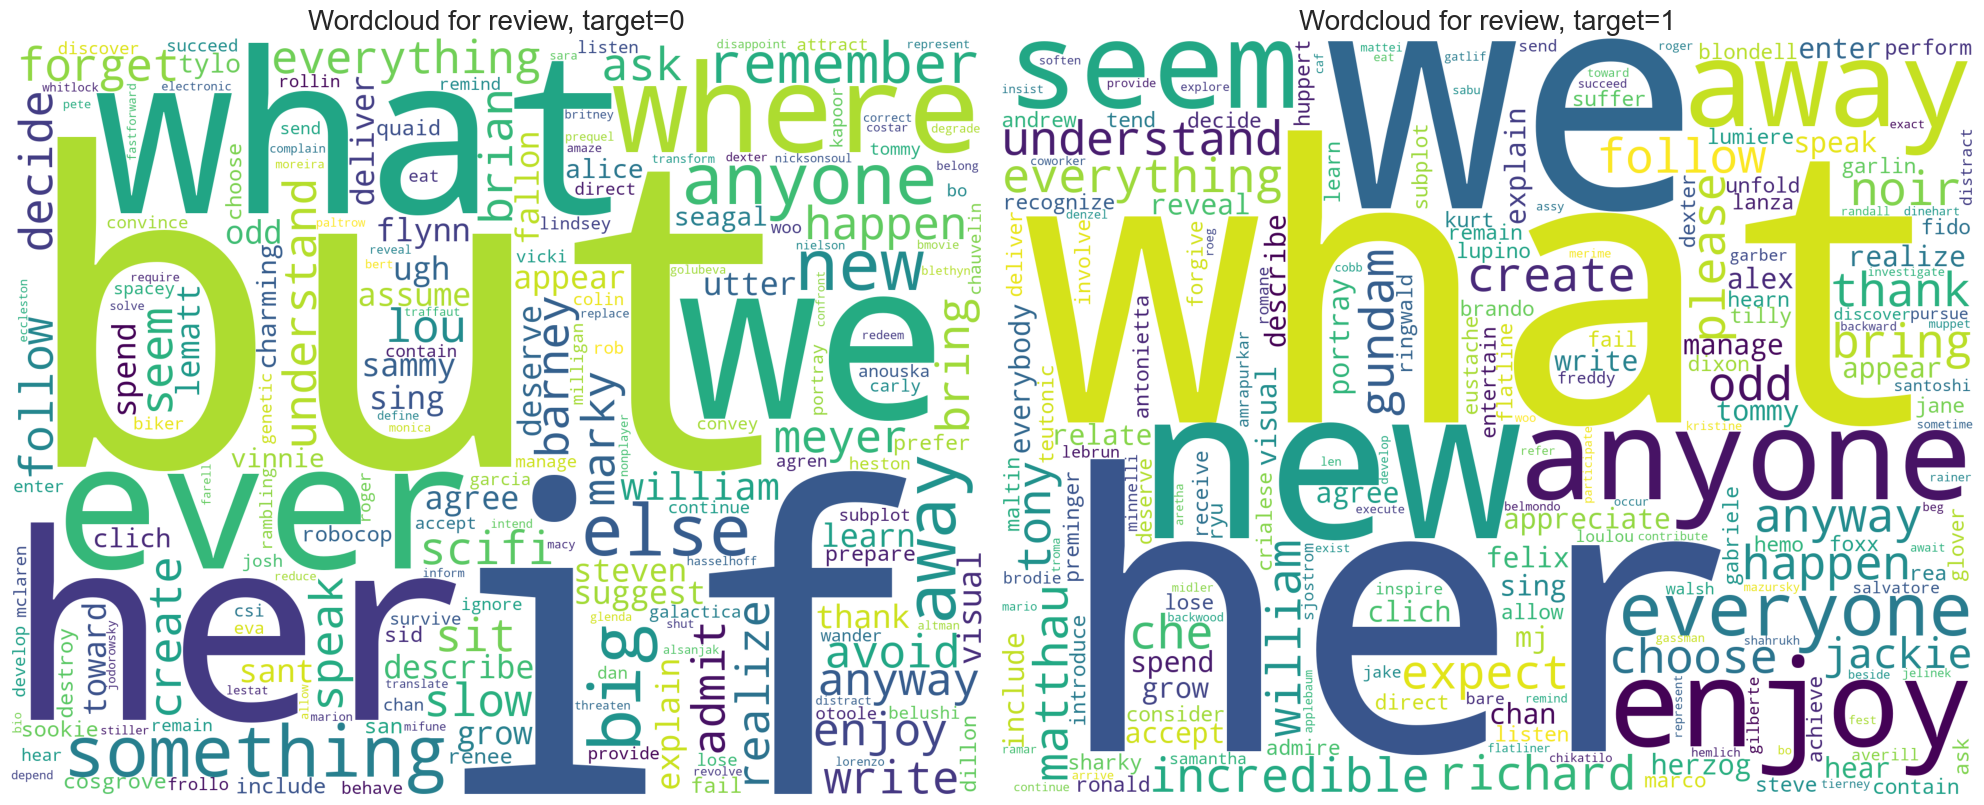

All Plots done
Time to run AutoViz = 7 seconds 

 ###################### AUTO VISUALIZATION Completed ########################


In [57]:
from autoviz.AutoViz_Class import AutoViz_Class

AV = AutoViz_Class()

dft = AV.AutoViz(
    filename="",
    sep=",",
    depVar="sentiment",
    dfte=df.sample(1000, random_state=42),
    header=0,
    verbose=0,
    lowess=False,
    chart_format="svg",
    max_rows_analyzed=1000,
    max_cols_analyzed=10
)